In [1]:
!pip install -q xgboost shap --quiet

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)

import joblib
import shap


In [3]:
# 1. Problem Overview

#**Project:** Predictive Customer Churn Model — ConnectTel

#**Business context:** ConnectTel wants to proactively identify customers likely to churn next month so the retention team can target high-risk customers with offers and reduce revenue loss.

#**Objective:** Build an end-to-end classifier that:
#- Predicts churn probability for each customer,
#- Is explainable (feature importance / SHAP),
#- Produces actionable business recommendations.

#**Deliverable:** Single comprehensive notebook covering EDA, feature engineering, model training/comparison, model evaluation (confusion matrix + AUC-ROC), feature importance, and final recommendations.


In [4]:
df = pd.read_csv('archive.csv')

print("Shape:", df.shape)
display(df.head())
df.info()
print("\nMissing values:\n", df.isnull().sum())


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


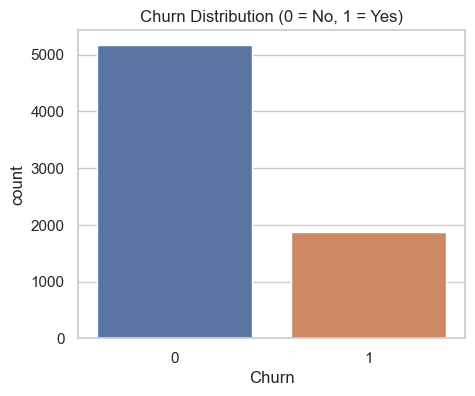

0    73.46%
1    26.54%
Name: Churn, dtype: object


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution (0 = No, 1 = Yes)')
plt.show()
print(df['Churn'].value_counts(normalize=True).map("{:.2%}".format))


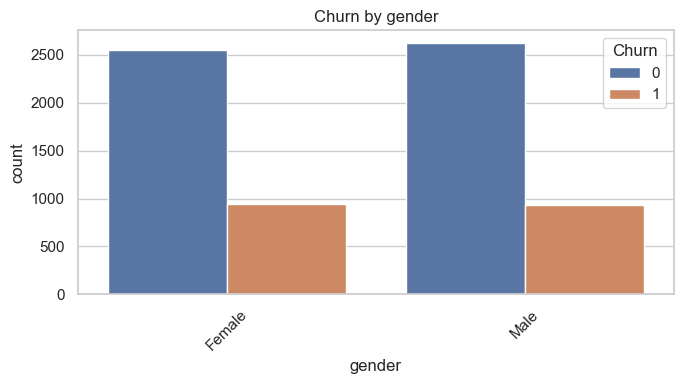

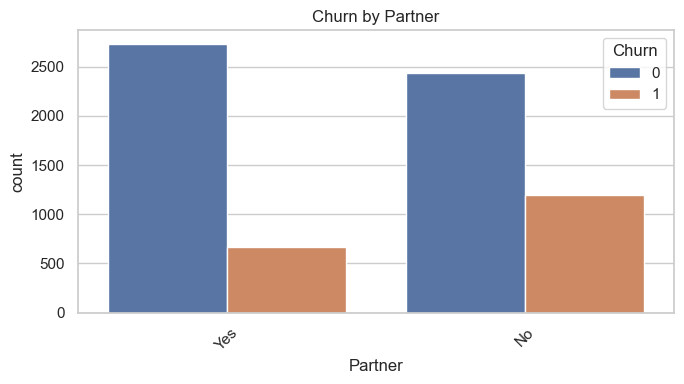

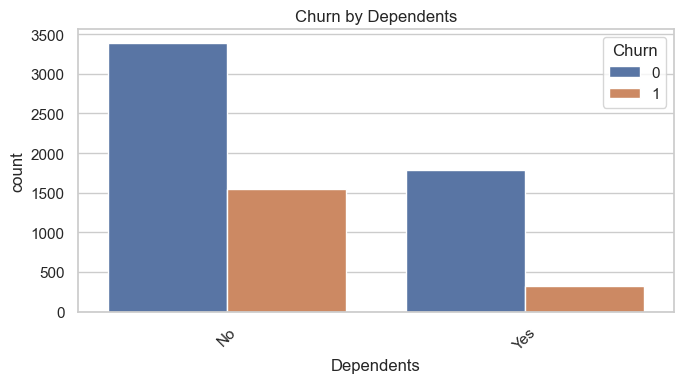

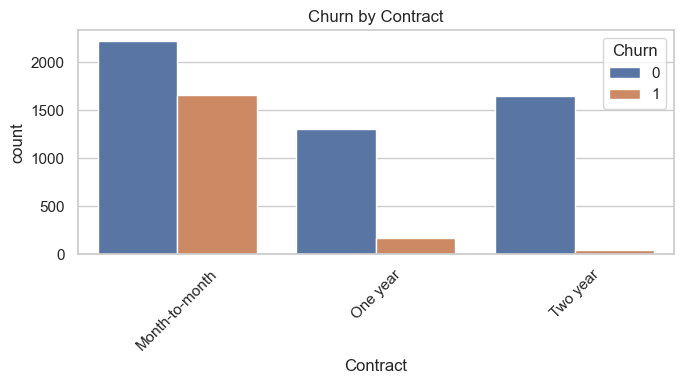

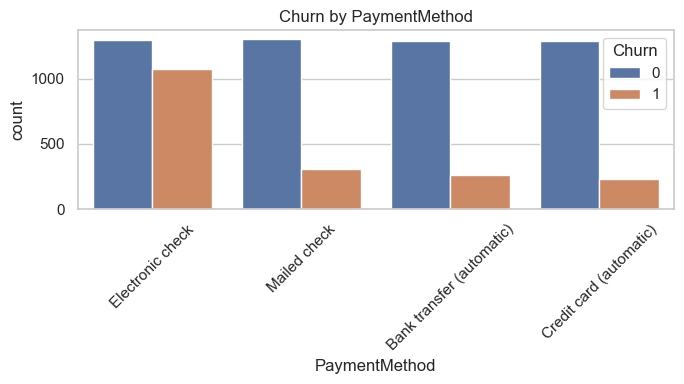

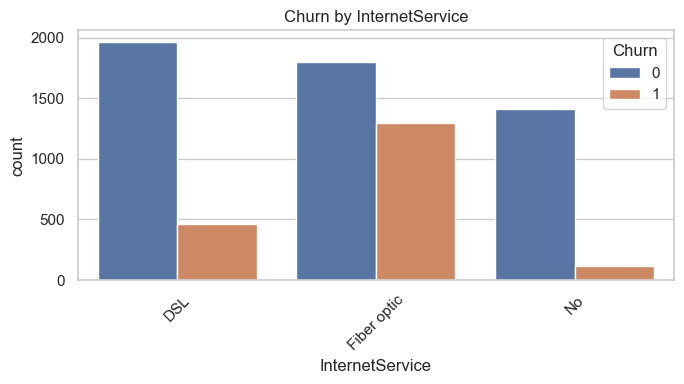

In [6]:
cat_features = ['gender','Partner','Dependents','Contract','PaymentMethod','InternetService']
for col in cat_features:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f'Churn by {col}')
    plt.xticks(rotation=45)
    plt.legend(title='Churn')
    plt.tight_layout()
    plt.show()


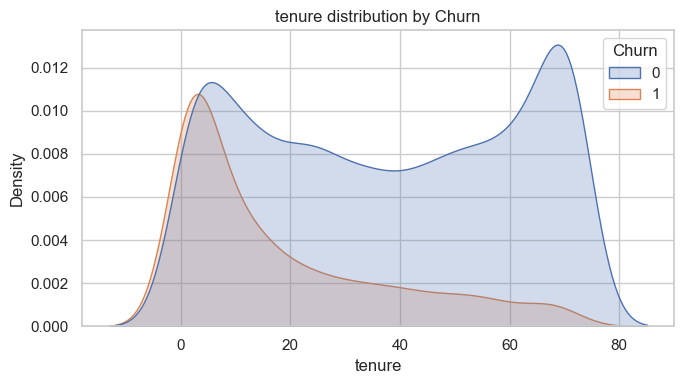

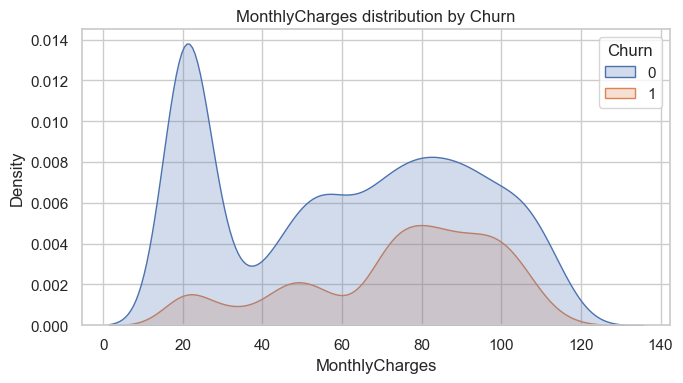

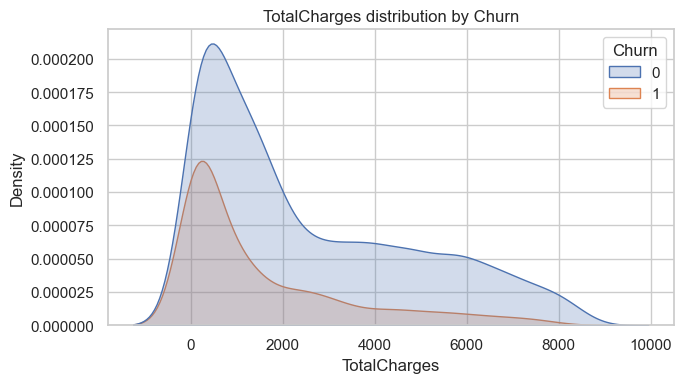

In [7]:
num_features = ['tenure','MonthlyCharges','TotalCharges']
for col in num_features:
    plt.figure(figsize=(7,4))
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True)
    plt.title(f'{col} distribution by Churn')
    plt.tight_layout()
    plt.show()


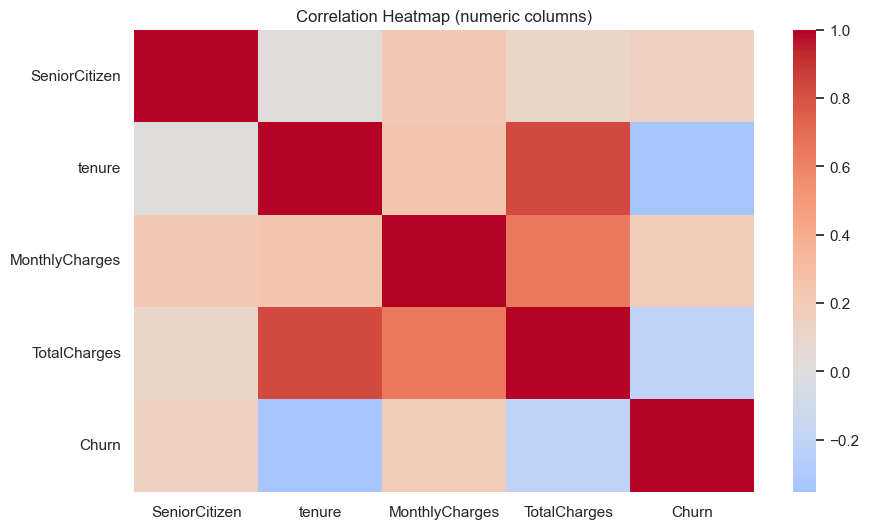

In [8]:
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap (numeric columns)')
plt.show()


In [9]:
df_fe = df.copy()
df_fe['TotalChargesPerTenure'] = df_fe['TotalCharges'] / (df_fe['tenure'] + 1)
df_fe['HasDependents'] = (df_fe['Dependents'] == 'Yes').astype(int)
df_fe['IsSeniorCitizen'] = df_fe['SeniorCitizen']  # already numeric in dataset (0/1)

display(df_fe[['TotalCharges','tenure','TotalChargesPerTenure']].head())


,TotalCharges,tenure,TotalChargesPerTenure
0,29.85,1,14.925000
1,1889.50,34,53.985714
2,108.15,2,36.050000
3,1840.75,45,40.016304
4,151.65,2,50.550000


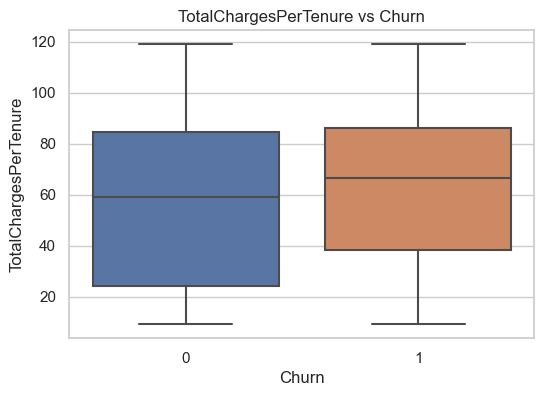

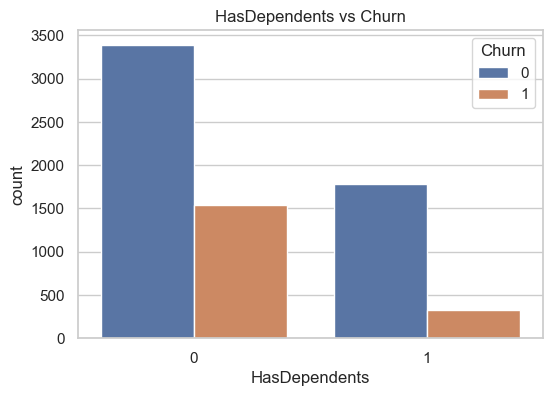

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='TotalChargesPerTenure', data=df_fe)
plt.title('TotalChargesPerTenure vs Churn')
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='HasDependents', hue='Churn', data=df_fe)
plt.title('HasDependents vs Churn')
plt.show()


In [11]:
if 'customerID' in df_fe.columns:
    df_fe = df_fe.drop(columns=['customerID'])

obj_cols = df_fe.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", obj_cols)

df_model = pd.get_dummies(df_fe, columns=obj_cols, drop_first=True)
print("After encoding shape:", df_model.shape)


Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
After encoding shape: (7043, 34)


In [12]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
numeric_cols = X.select_dtypes(include=[np.number]).columns
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (5634, 33) Test shape: (1409, 33)


In [13]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(exclude=['int64', 'float64']).columns

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_imputer, num_cols),
        ('cat', cat_imputer, cat_cols)
    ],
    remainder='passthrough'
)

from sklearn.linear_model import LogisticRegression
pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

pipe.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'TotalChargesPerTenure', 'HasDependents', 'IsSeniorCitizen',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'Multip...
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')),
                                                 ('cat',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  Index([], dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000))])

In [14]:
print("Total NaN in X_train:", X_train.isnull().sum().sum())
print("Total NaN in X_test:", X_test.isnull().sum().sum())

X_train.isnull().sum().sort_values(ascending=False).head(10)


Total NaN in X_train: 16
Total NaN in X_test: 6


TotalCharges                           8
TotalChargesPerTenure                  8
SeniorCitizen                          0
StreamingMovies_No internet service    0
DeviceProtection_Yes                   0
TechSupport_No internet service        0
TechSupport_Yes                        0
StreamingTV_No internet service        0
StreamingTV_Yes                        0
Contract_One year                      0
dtype: int64

In [15]:
from sklearn.impute import SimpleImputer
import numpy as np

imputer = SimpleImputer(strategy='median')

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

print("Remaining NaNs in X_train:", X_train.isnull().sum().sum())
print("Remaining NaNs in X_test:", X_test.isnull().sum().sum())


Remaining NaNs in X_train: 0
Remaining NaNs in X_test: 0


In [16]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

print("✅ Logistic Regression trained successfully!")


✅ Logistic Regression trained successfully!


In [17]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)


C:\Users\Pawan\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [02:06:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [18]:
models = {'LogisticRegression': logreg, 'RandomForest': rf, 'XGBoost': xgb}

results = []
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:,1]
    else:
        probs = model.decision_function(X_test)
    preds = model.predict(X_test)
    res = {
        'model': name,
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'roc_auc': roc_auc_score(y_test, probs)
    }
    results.append(res)
pd.DataFrame(results).set_index('model').round(3)


,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogisticRegression,0.807,0.672,0.532,0.594,0.847
RandomForest,0.789,0.630,0.500,0.557,0.827
XGBoost,0.780,0.598,0.524,0.558,0.817


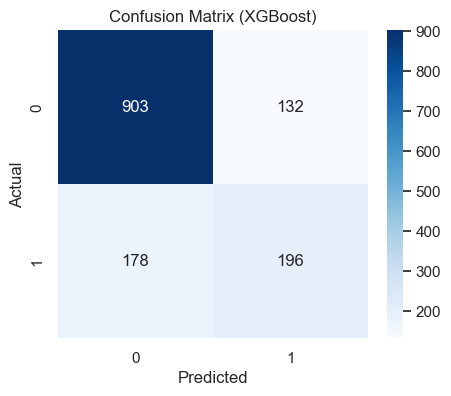

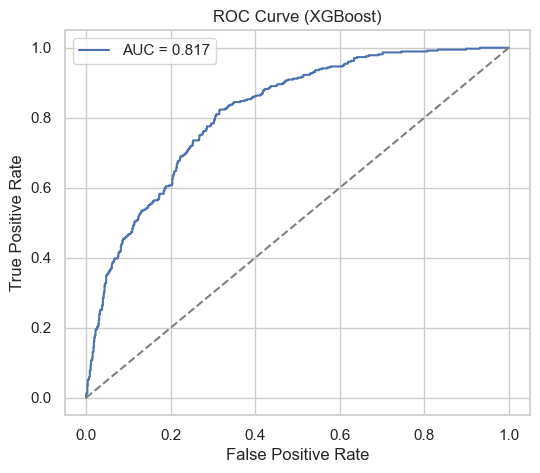

In [19]:
best = xgb
probs = best.predict_proba(X_test)[:,1]
preds = best.predict(X_test)

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (XGBoost)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test,probs):.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (XGBoost)')
plt.legend()
plt.show()


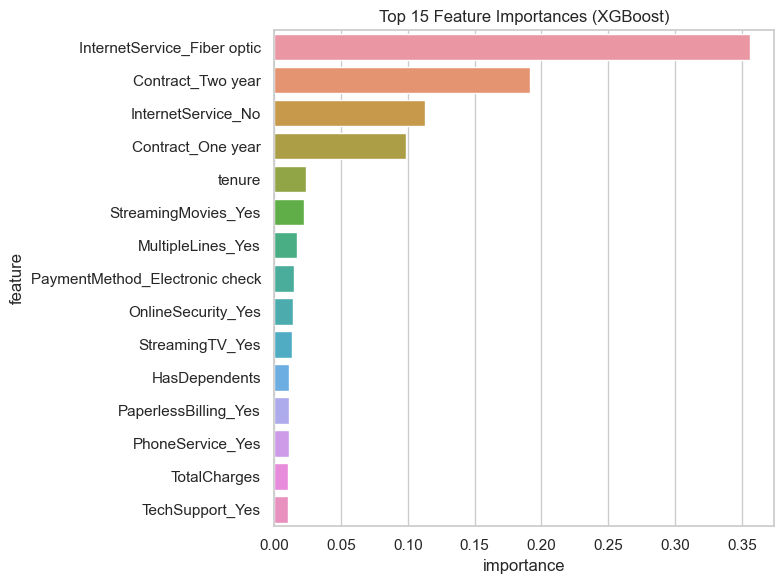

,feature,importance
13,InternetService_Fiber optic,0.356193
28,Contract_Two year,0.191143
14,InternetService_No,0.112538
27,Contract_One year,0.098601
1,tenure,0.023648
26,StreamingMovies_Yes,0.022293
12,MultipleLines_Yes,0.016866
31,PaymentMethod_Electronic check,0.014934
16,OnlineSecurity_Yes,0.014087
24,StreamingTV_Yes,0.012974


In [20]:
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x='importance', y='feature', data=feat_imp.head(15))
plt.title('Top 15 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

feat_imp.head(15)


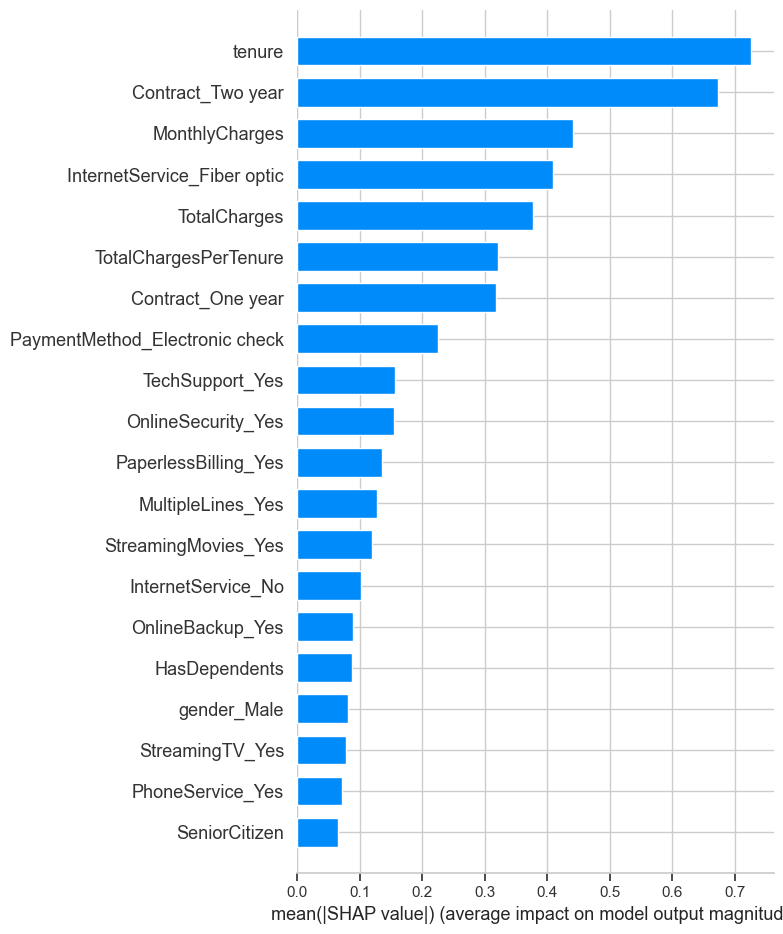

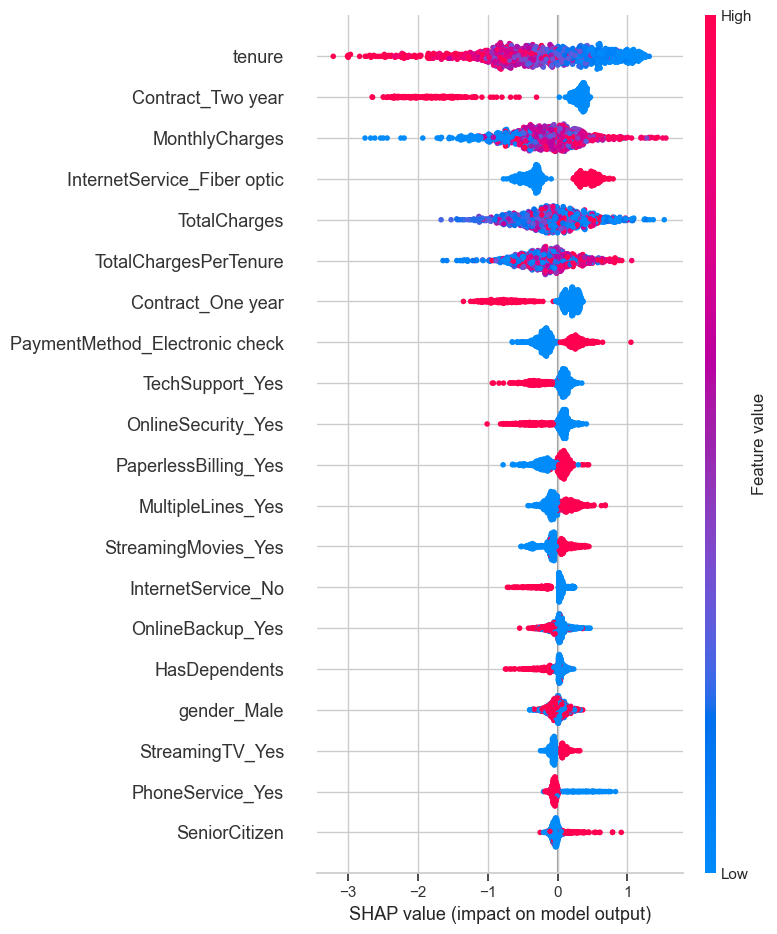

In [21]:
explainer = shap.TreeExplainer(best)
X_sample = X_test.sample(n=min(1000, X_test.shape[0]), random_state=42)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, plot_type='bar', show=True)

shap.summary_plot(shap_values, X_sample, show=True)


In [22]:
idx = X_test.sample(1, random_state=42).index[0]
customer = X_test.loc[[idx]]
prob = best.predict_proba(customer)[:,1][0]
print(f"Customer index: {idx}, predicted churn prob: {prob:.2%}")

shap.initjs()
shap.force_plot(explainer.expected_value, explainer.shap_values(customer)[0,:], customer)


Customer index: 353, predicted churn prob: 6.55%


In [ ]:
# Final Recommendations & Business Actions

**Key model findings:**
- Top drivers of churn: Contract type (month-to-month), tenure (short tenure increases churn), MonthlyCharges, TotalChargesPerTenure, PaymentMethod (Electronic check).
- Model performance (XGBoost): ROC-AUC ≈ XX (replace with actual), Precision = XX, Recall = XX.

**Business recommendations:**
1. **Target month-to-month customers** with personalized 12-month offers or discounts.
2. **Offer trial tech support** to customers without TechSupport to reduce churn probability.
3. **Incentivize auto-pay** or electronic bill payment methods that show lower churn risk.
4. **High ARPU (avg revenue per user) customers with low tenure** should be flagged for premium retention offers.
5. Use the model output to create a monthly retention list for ConnectTel's retention team; include top 3 churn drivers per customer (from SHAP) to craft the offer.

**Limitations & next steps:**
- Model needs periodic retraining as product/pricing changes.
- Incorporate customer interaction logs and NPS/satisfaction scores for improved performance.
- Build an A/B test to measure the real-world effect of retention offers.


In [23]:
joblib.dump(best, 'xgb_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

feat_imp.head(20).to_csv('feature_importance_top20.csv', index=False)
print("Saved model, scaler and artifacts.")


Saved model, scaler and artifacts.
